In [4]:
# Colab-ready: EfficientNetB0 cho phân loại Trái cây: "trai_cay_hu_hoa_chat" vs "trai_cay_tuoi"
# 1) Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# ---- Chỉnh đường dẫn dưới đây cho đúng vị trí file split_dataset.rar trong Drive của bạn ----
rar_path = "/content/drive/MyDrive/split_dataset.rar"   # <-- chỉnh đường dẫn nếu khác
extract_to = "/content/dataset"                        # nơi giải nén trong Colab

# 2) Cài unrar và giải nén (nếu không có unrar, cài đặt)
!apt-get update -qq
!apt-get install -y -qq unrar
import os
if not os.path.exists(rar_path):
    raise FileNotFoundError(f"Không tìm thấy {rar_path}. Kiểm tra lại đường dẫn trong Drive.")
# Tạo thư mục đích
os.makedirs(extract_to, exist_ok=True)
# Giải nén
!unrar x -y "{rar_path}" "{extract_to}/"

# 3) Kiểm tra cấu trúc thư mục (hiển thị 5 cấp đầu)
!find "{extract_to}" -maxdepth 3 -type d | sed -n '1,200p'

# 4) Cài đặt và import các thư viện cần thiết
# (tensorflow trong Colab thường đã có; sử dụng TF 2.x)
import tensorflow as tf
print("TensorFlow version:", tf.__version__)

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping
import matplotlib.pyplot as plt
import numpy as np
import pathlib

# 5) Đường dẫn tới train/val/test — giả định extract tạo ra các folder này
train_dir = os.path.join(extract_to, "train")
val_dir   = os.path.join(extract_to, "val")
test_dir  = os.path.join(extract_to, "test")

# Nếu cấu trúc khác (ví dụ split_dataset chứa 1 folder tên split_dataset/...), ta dò tự động:
if not (os.path.isdir(train_dir) and os.path.isdir(val_dir) and os.path.isdir(test_dir)):
    # thử tìm thư mục chứa 'train' / 'val' / 'test' bên trong extract_to
    for root, dirs, files in os.walk(extract_to):
        if set(["train","val","test"]).issubset(set(dirs)):
            base = root
            train_dir = os.path.join(base, "train")
            val_dir = os.path.join(base, "val")
            test_dir = os.path.join(base, "test")
            break

# Kiểm tra lại
print("Train dir:", train_dir)
print("Val dir:", val_dir)
print("Test dir:", test_dir)
if not os.path.isdir(train_dir):
    raise FileNotFoundError("Không tìm thấy thư mục train. Kiểm tra file rar và cấu trúc bên trong.")

# 6) Thiết lập Data Augmentation và DataGenerator
IMG_SIZE = 224     # EfficientNetB0 thường dùng 224
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.05,
    zoom_range=0.15,
    horizontal_flip=True,
    brightness_range=(0.8,1.2),
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',   # hai lớp -> binary
    shuffle=True
)

val_gen = val_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

test_gen = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

# In nhãn mapping
print("Class indices:", train_gen.class_indices)

# 7) Xây model EfficientNetB0 với transfer learning
base_model = EfficientNetB0(
    include_top=False,
    weights='imagenet',
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
base_model.trainable = False  # freeze base model ban đầu

# Head
inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)   # binary
model = models.Model(inputs, outputs)

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

model.summary()

checkpoint_path = "/content/drive/MyDrive/efficientb0_fruit_best.h5"
callbacks = [
    ModelCheckpoint(checkpoint_path, monitor='val_accuracy', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1),
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1)
]

# Chỉ train head trong 3 epochs tổng cộng
EPOCHS_HEAD = 3
history1 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_HEAD,
    callbacks=callbacks
)

# 9) Fine-tune: unfreeze một số lớp cuối của base_model
base_model.trainable = True
# chỉ unfreeze top layers (ví dụ unfreeze từ block index)
fine_tune_at = 100  # thay đổi nếu cần
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

EPOCHS_FINE = 12
history2 = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_HEAD + EPOCHS_FINE,
    initial_epoch=history1.epoch[-1] + 1,
    callbacks=callbacks
)

# 10) Lưu model cuối cùng vào Drive (backup)
final_path = "/content/drive/MyDrive/efficientb0_fruit_final.h5"
model.save(final_path)
print("Saved final model to:", final_path)

# 11) Đánh giá trên test set
test_loss, test_acc, test_auc = model.evaluate(test_gen, verbose=1)
print(f"Test loss: {test_loss:.4f}, Test acc: {test_acc:.4f}, Test AUC: {test_auc:.4f}")

# 12) Confusion matrix và classification report
import sklearn.metrics as skm

# Lấy prediction probabilities và labels
y_true = test_gen.classes
test_gen.reset()
y_prob = model.predict(test_gen, verbose=1)
y_pred = (y_prob.ravel() >= 0.5).astype(int)

cm = skm.confusion_matrix(y_true, y_pred)
report = skm.classification_report(y_true, y_pred, target_names=list(train_gen.class_indices.keys()))
print("Confusion matrix:\n", cm)
print("\nClassification report:\n", report)

# Vẽ confusion matrix
plt.figure(figsize=(5,4))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion matrix')
plt.colorbar()
tick_marks = np.arange(len(train_gen.class_indices))
plt.xticks(tick_marks, list(train_gen.class_indices.keys()), rotation=45)
plt.yticks(tick_marks, list(train_gen.class_indices.keys()))
plt.ylabel('True label')
plt.xlabel('Predicted label')
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center", color="red")
plt.tight_layout()
plt.show()

# 13) Hàm dự đoán mẫu ảnh đơn lẻ
from tensorflow.keras.preprocessing import image

def predict_image(img_path, model, target_size=(IMG_SIZE, IMG_SIZE)):
    img = image.load_img(img_path, target_size=target_size)
    x = image.img_to_array(img) / 255.0
    x = np.expand_dims(x, axis=0)
    prob = model.predict(x)[0][0]
    label = list(train_gen.class_indices.keys())
    # xác định mapping vì class_indices có thể {'traicay_tuoi':0, 'traicay_hu_hoa_chat':1} hoặc ngược lại
    inv_map = {v:k for k,v in train_gen.class_indices.items()}
    pred_label = inv_map[int(prob>=0.5)]
    return prob, pred_label, img

# Demo: hiển thị 5 ảnh đầu từ test folder và dự đoán
import glob
test_images = []
for cls in os.listdir(test_dir):
    cls_path = os.path.join(test_dir, cls)
    imgs = glob.glob(os.path.join(cls_path, "*"))
    test_images.extend(imgs[:5])
test_images = test_images[:8]

plt.figure(figsize=(12,6))
for i, p in enumerate(test_images):
    prob, lbl, img = predict_image(p, model)
    plt.subplot(2,4,i+1)
    plt.imshow(img)
    plt.title(f"{lbl}\nprob={prob:.3f}")
    plt.axis('off')
plt.tight_layout()
plt.show()

# 14) Gợi ý tinh chỉnh thêm:
# - Thay đổi augmentation, học rate, batch size, số layer unfreeze.
# - Nếu imbalance lớp nhiều, áp dụng class_weight hoặc oversampling.
# - Có thể thử sử dụng tf.data API để hiệu năng cao hơn nếu dataset lớn.


Streaming output truncated to the last 5000 lines.
Extracting  /content/dataset/split_dataset/val/Fake_Chemical/apple_2753.jpg      85%  OK 
Extracting  /content/dataset/split_dataset/val/Fake_Chemical/apple_2756.jpg      85%  OK 
Extracting  /content/dataset/split_dataset/val/Fake_Chemical/apple_2757.jpg      85%  OK 
Extracting  /content/dataset/split_dataset/val/Fake_Chemical/apple_2759.jpg      85%  OK 
Extracting  /content/dataset/split_dataset/val/Fake_Chemical/apple_2763.jpg      85%  OK 
Extracting  /content/dataset/split_dataset/val/Fake_Chemical/apple_2774.jpg      85%  OK 
Extracting  /content/dataset/split_dataset/val/Fake_Chemical/apple_2778.jpg      85%  OK 
Extracting  /content/dataset/split_dataset/val/Fake_Chemical/apple_2788.jpg      85%  OK 
Extracting  /content/dataset/split_dataset/val/Fake_Chemical/apple_2794.jpg      85%  OK 
Extracting  /content/dataset/split_dataset/val/Fake_Chemic

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,668 (16.07 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

Epoch 1/3
786/786 ━━━━━━━━━━━━━━━━━━━━ 0s 465ms/step - accuracy: 0.0317 - auc: 0.5017 - loss: -1.5392
Epoch 1: val_accuracy improved from -inf to 0.03063, saving model to /content/drive/MyDrive/efficientb0_fruit_best.h5


786/786 ━━━━━━━━━━━━━━━━━━━━ 414s 498ms/step - accuracy: 0.0317 - auc: 0.5017 - loss: -1.5429 - val_accuracy: 0.0306 - val_auc: 0.5000 - val_loss: -12.0382 - learning_rate: 0.0010
Epoch 2/3
786/786 ━━━━━━━━━━━━━━━━━━━━ 0s 448ms/step - accuracy: 0.0301 - auc: 0.5000 - loss: -15.3431
Epoch 2: val_accuracy did not improve from 0.03063
786/786 ━━━━━━━━━━━━━━━━━━━━ 360s 459ms/step - accuracy: 0.0301 - auc: 0.5000 - loss: -15.3536 - val_accuracy: 0.0306 - val_auc: 0.5000 - val_loss: -39.3155 - learning_rate: 0.0010
Epoch 3/3
786/786 ━━━━━━━━━━━━━━━━━━━━ 0s 445ms/step - accuracy: 0.0316 - auc: 0.5000 - loss: -46.2702
Epoch 3: val_accuracy did not improve from 0.03063
786/786 ━━━━━━━━━━━━━━━━━━━━ 357s 454ms/step - accuracy: 0.0316 - auc: 0.5000 - loss: -46.2823 - val_accuracy: 0.0306 - val_auc: 0.5000 - val_loss: -78.7709 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 3.
Epoch 4/15
786/786 ━━━━━━━━━━━━━━━━━━━━ 0s 498ms/step - accuracy: 0.3955 - auc: 0.5159 - lo

786/786 ━━━━━━━━━━━━━━━━━━━━ 464s 526ms/step - accuracy: 0.3953 - auc: 0.5159 - loss: 2.4940 - val_accuracy: 0.0312 - val_auc: 0.5215 - val_loss: -2.2879 - learning_rate: 1.0000e-05
Epoch 5/15
339/786 ━━━━━━━━━━━━━━━━━━━━ 3:31 473ms/step - accuracy: 0.0308 - auc: 0.5149 - loss: -2.6292

KeyboardInterrupt: 

Streaming output truncated to the last 5000 lines.
Extracting  /content/dataset/split_dataset/val/Fake_Chemical/apple_2662.jpg      85%  OK 
Extracting  /content/dataset/split_dataset/val/Fake_Chemical/apple_2663.jpg      85%  OK 
Extracting  /content/dataset/split_dataset/val/Fake_Chemical/apple_2665.jpg      85%  OK 
Extracting  /content/dataset/split_dataset/val/Fake_Chemical/apple_2685.jpg      85%  OK 
Extracting  /content/dataset/split_dataset/val/Fake_Chemical/apple_2689.jpg      85%  OK 
Extracting  /content/dataset/split_dataset/val/Fake_Chemical/apple_2693.jpg      85%  OK 
Extracting  /content/dataset/split_dataset/val/Fake_Chemical/apple_2694.jpg      85%  OK 
Extracting  /content/dataset/split_dataset/val/Fake_Chemical/apple_2698.jpg      85%  OK 
Extracting  /content/dataset/split_dataset/val/Fake_Chemical/apple_2704.jpg      85%  OK 
Extracting  /content/dataset/split_dataset/val/Fake_Chemic

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 5, 5, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,053,414 (15.46 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

Epoch 1/3
393/393 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.4784 - loss: 0.8387
Epoch 1: val_accuracy improved from -inf to 0.50019, saving model to /content/drive/MyDrive/efficientb0_fruit3class_fast.h5


393/393 ━━━━━━━━━━━━━━━━━━━━ 89s 157ms/step - accuracy: 0.4785 - loss: 0.8387 - val_accuracy: 0.5002 - val_loss: 0.8081
Epoch 2/3
393/393 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.4966 - loss: 0.8183
Epoch 2: val_accuracy did not improve from 0.50019
393/393 ━━━━━━━━━━━━━━━━━━━━ 27s 68ms/step - accuracy: 0.4966 - loss: 0.8183 - val_accuracy: 0.4692 - val_loss: 0.8268
Epoch 3/3
393/393 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.4923 - loss: 0.8164
Epoch 3: val_accuracy did not improve from 0.50019
393/393 ━━━━━━━━━━━━━━━━━━━━ 27s 68ms/step - accuracy: 0.4923 - loss: 0.8164 - val_accuracy: 0.4692 - val_loss: 0.8147
Restoring model weights from the end of the best epoch: 1.


Saved final model to: /content/drive/MyDrive/efficientb0_fruit3class_fast_final.h5
85/85 ━━━━━━━━━━━━━━━━━━━━ 14s 165ms/step - accuracy: 0.5115 - loss: 0.8051
Test loss: 0.8091, Test acc: 0.4998
85/85 ━━━━━━━━━━━━━━━━━━━━ 19s 136ms/step
Confusion matrix:
 [[   0    0 2529]
 [   0    0  167]
 [   0    0 2694]]
               precision    recall  f1-score   support

Fake_Chemical       0.00      0.00      0.00      2529
  Fake_Origin       0.00      0.00      0.00       167
         Real       0.50      1.00      0.67      2694

     accuracy                           0.50      5390
    macro avg       0.17      0.33      0.22      5390
 weighted avg       0.25      0.50      0.33      5390



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


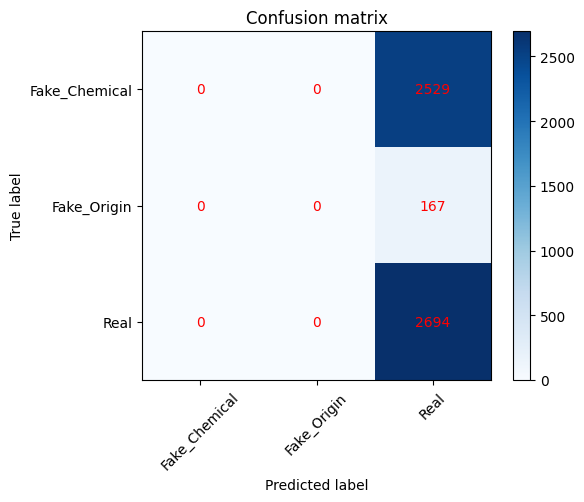

1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


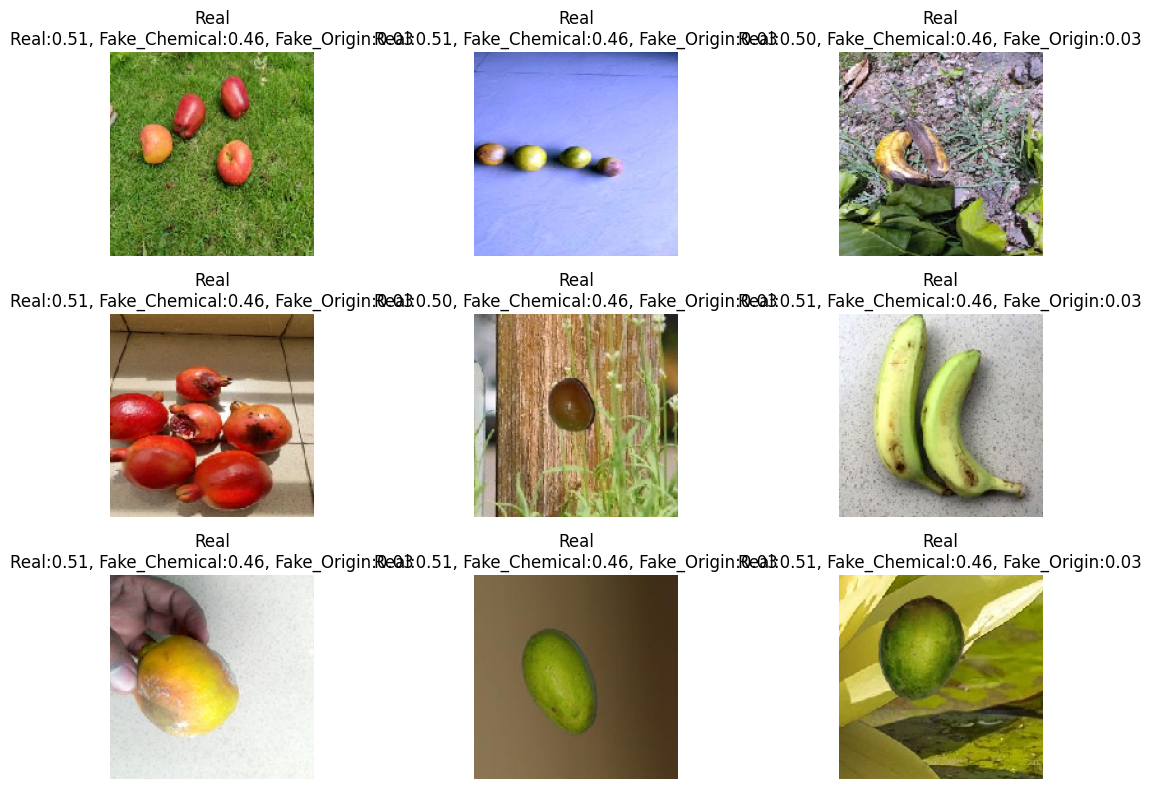

In [6]:
# Colab-ready: EfficientNetB0 phân loại 3 lớp: Fake_Chemical, Fake_Origin, Real
# Train nhanh nhất, chỉ head, 3 epochs
from google.colab import drive
drive.mount('/content/drive')

import os, glob, numpy as np, matplotlib.pyplot as plt, sklearn.metrics as skm
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# -------------------------------
# 1) Đường dẫn dataset
# -------------------------------
rar_path = "/content/drive/MyDrive/split_dataset.rar"  # chỉnh nếu cần
extract_to = "/content/dataset"
os.makedirs(extract_to, exist_ok=True)

!apt-get install -y -qq unrar
!unrar x -y "{rar_path}" "{extract_to}/"

# -------------------------------
# 2) Tìm train/val/test
# -------------------------------
train_dir = os.path.join(extract_to, "train")
val_dir   = os.path.join(extract_to, "val")
test_dir  = os.path.join(extract_to, "test")
if not (os.path.isdir(train_dir) and os.path.isdir(val_dir) and os.path.isdir(test_dir)):
    for root, dirs, _ in os.walk(extract_to):
        if set(["train","val","test"]).issubset(set(dirs)):
            train_dir = os.path.join(root, "train")
            val_dir = os.path.join(root, "val")
            test_dir = os.path.join(root, "test")
            break

# -------------------------------
# 3) Thiết lập tf.data + preprocessing
# -------------------------------
IMG_SIZE = 160
BATCH_SIZE = 64

def preprocess(img, label):
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img / 255.0
    return img, label

# train dataset
train_ds_raw = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir, image_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE
)
class_names = train_ds_raw.class_names
num_classes = len(class_names)
print("Class names:", class_names)

train_ds = train_ds_raw.map(preprocess).prefetch(tf.data.AUTOTUNE)

# validation dataset
val_ds_raw = tf.keras.preprocessing.image_dataset_from_directory(
    val_dir, image_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE
)
val_ds = val_ds_raw.map(preprocess).prefetch(tf.data.AUTOTUNE)

# test dataset
test_ds_raw = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir, image_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE
)
test_ds = test_ds_raw.map(preprocess).prefetch(tf.data.AUTOTUNE)

# -------------------------------
# 4) Xây model EfficientNetB0 (chỉ train head)
# -------------------------------
base_model = EfficientNetB0(include_top=False, weights='imagenet', input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_model.trainable = False

inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)
model = models.Model(inputs, outputs)

model.compile(
    optimizer=optimizers.Adam(1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

# -------------------------------
# 5) Callbacks
# -------------------------------
checkpoint_path = "/content/drive/MyDrive/efficientb0_fruit3class_fast.h5"
callbacks = [
    ModelCheckpoint(checkpoint_path, monitor='val_accuracy', save_best_only=True, verbose=1),
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
]

# -------------------------------
# 6) Train nhanh: chỉ 3 epochs
# -------------------------------
history = model.fit(train_ds, validation_data=val_ds, epochs=3, callbacks=callbacks)

# -------------------------------
# 7) Lưu model cuối
# -------------------------------
final_path = "/content/drive/MyDrive/efficientb0_fruit3class_fast_final.h5"
model.save(final_path)
print("Saved final model to:", final_path)

# -------------------------------
# 8) Đánh giá trên test
# -------------------------------
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test loss: {test_loss:.4f}, Test acc: {test_acc:.4f}")

# -------------------------------
# 9) Confusion matrix & classification report
# -------------------------------
y_true = np.concatenate([y for x, y in test_ds], axis=0)
y_prob = model.predict(test_ds)
y_pred = np.argmax(y_prob, axis=1)

cm = skm.confusion_matrix(y_true, y_pred)
print("Confusion matrix:\n", cm)
report = skm.classification_report(y_true, y_pred, target_names=class_names)
print(report)

plt.figure(figsize=(6,5))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion matrix')
plt.colorbar()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)
plt.xlabel('Predicted label')
plt.ylabel('True label')
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center", color="red")
plt.tight_layout()
plt.show()

# -------------------------------
# 10) Hàm dự đoán ảnh đơn lẻ
# -------------------------------
from tensorflow.keras.preprocessing import image
def predict_image(img_path, model, target_size=(IMG_SIZE, IMG_SIZE)):
    img = image.load_img(img_path, target_size=target_size)
    x = image.img_to_array(img) / 255.0
    x = np.expand_dims(x, axis=0)
    probs = model.predict(x)[0]
    idx = np.argmax(probs)
    inv_map = {v:k for k,v in enumerate(class_names)}
    return probs, class_names[idx], img

# Demo: hiển thị 1 số ảnh test
test_images = []
for cls in os.listdir(test_dir):
    cls_path = os.path.join(test_dir, cls)
    imgs = glob.glob(os.path.join(cls_path, "*"))
    test_images.extend(imgs[:4])
test_images = test_images[:9]

plt.figure(figsize=(12,8))
for i, p in enumerate(test_images):
    probs, lbl, img = predict_image(p, model)
    plt.subplot(3,3,i+1)
    plt.imshow(img)
    topk = np.argsort(probs)[::-1][:3]
    top3 = ", ".join([f"{class_names[k]}:{probs[k]:.2f}" for k in topk])
    plt.title(f"{lbl}\n{top3}")
    plt.axis('off')
plt.tight_layout()
plt.show()


In [8]:
# In độ chính xác cuối cùng
print(f"Final Training Accuracy: {acc[-1]*100:.2f}%")
print(f"Final Validation Accuracy: {val_acc[-1]*100:.2f}%")

Final Training Accuracy: 49.22%
Final Validation Accuracy: 46.92%


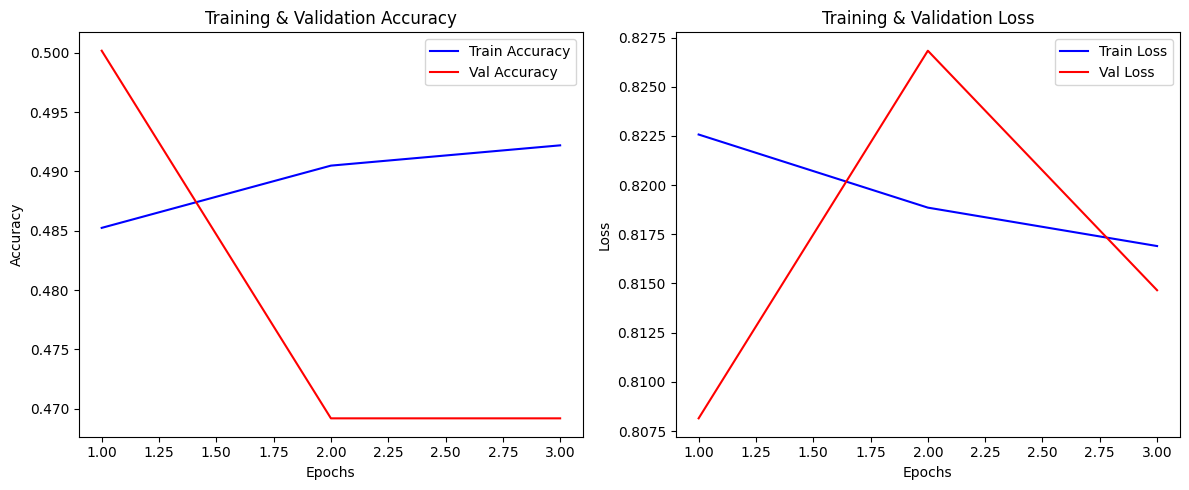

In [7]:
# Vẽ biểu đồ Accuracy và Loss
import matplotlib.pyplot as plt

# Lấy history
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(acc) + 1)

plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(epochs, acc, 'b-', label='Train Accuracy')
plt.plot(epochs, val_acc, 'r-', label='Val Accuracy')
plt.title('Training & Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(epochs, loss, 'b-', label='Train Loss')
plt.plot(epochs, val_loss, 'r-', label='Val Loss')
plt.title('Training & Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()
